# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import norm
from seaborn import residplot

In [2]:
data = np.genfromtxt('data_01.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']

In [3]:
fit, cov = np.polyfit(x, y, 1, w=1/sigma_y, cov=True)
m, b = fit
m_err, b_err = np.sqrt(np.diag(cov))

print(f"Slope: m = {m:.4f} +/- {m_err:.4f}")
print(f"Intercept: b = {b:.4f} +/- {b_err:.4f}")

Slope: m = 1.3027 +/- 0.7594
Intercept: b = 30.7822 +/- 4.8422


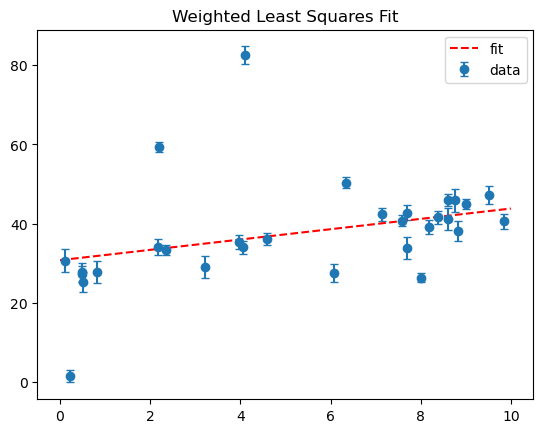

In [4]:
xx = np.linspace(0, 10, 200)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, m * xx + b, 'r--', label='fit')
plt.title('Weighted Least Squares Fit')
plt.legend()
plt.show()

In [5]:
n = len(x)
residual = y - np.polyval(fit, x)
chi2 = np.sum((residual/sigma_y)**2)
chi2_reduced = chi2 / (n - 2)

print(f"Chi2 Reduced = {chi2_reduced:.2f}")

Chi2 Reduced = 52.06


**ANSWER (a few sentences):**

I calculated a reduced chi2 of 52.06. Given that a correct model will report a reduced chi2 around 1, my value tells us there is something wrong with the model or uncertainties. There is something going on with the fit due to the outliers in my data.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

In [6]:
# Part 2: your work here

#sigma-clipping
def sigma_clip(x, y, sigma, k, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        fit_k, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        residual = (y - np.polyval(fit_k, x))/sigma
        n_mask = np.abs(residual) < k
        if np.array_equal(n_mask, mask):
            break
        mask = n_mask
    m_k, b_k = fit_k
    m_err_k, b_err_k = np.sqrt(np.diag(cov))
    return fit, mask, m_k, b_k, m_err_k, b_err_k, residual

fit_k, mask, m_k, b_k, m_err_k, b_err_k, resid_k = sigma_clip(x, y, sigma_y, k=3.0)
print("Sigma-clip")
print(f"Slope: m = {m_k:.4f} +/- {m_err_k:.4f}")
print(f"Intercept: b = {b_k:.4f} +/- {b_err_k:.4f}")

Sigma-clip
Slope: m = 1.7215 +/- 0.1653
Intercept: b = 27.9412 +/- 1.0966


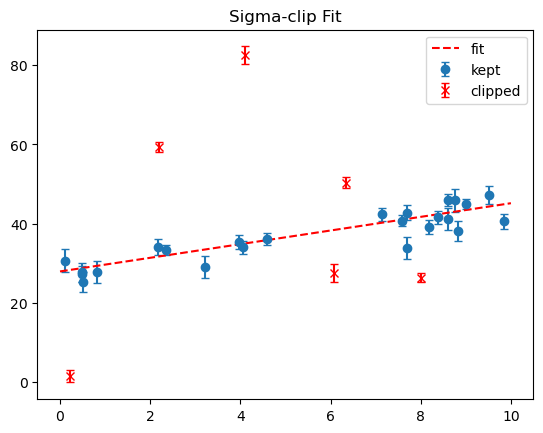

In [7]:
plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color = 'r', label='clipped')
plt.plot(xx, m_k * xx + b_k, 'r--', label='fit')
plt.title('Sigma-clip Fit')
plt.legend()
plt.show()

In [8]:
#mixture model

def neg_log_lh(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m*x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad + 1e-300))

theta = [fit_k[0], fit_k[1], 0.2, np.mean(y), np.log(50.0)]
mix = minimize(neg_log_lh, theta, args = (x, y, sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = mix.x


In [12]:
rng_bs = np.random.default_rng(20260908)
n_boot = 1000

boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for i in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    theta = [fit_k[0], fit_k[1], 0.2, np.mean(y), np.log(50.0)]
    mix = minimize(neg_log_lh, theta, args = (x[idx], y[idx], sigma_y[idx]), method='Nelder-Mead')
    m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = mix.x
    boot_slopes[i] = m_mix
    boot_intercepts[i] = b_mix

lo_s, hi_s = np.percentile(boot_slopes, [16, 84])
lo_b, hi_b = np.percentile(boot_intercepts, [16, 84])
m_err_mix = hi_s - lo_s
b_err_mix = hi_b - lo_b

In [19]:
print("Mixture fit")
print(f"Slope = {m_mix:.4f} +/- {m_err_mix:.4f}")
print(f"Intercept = {b_mix:.2f} +/- {b_err_mix:.4f}")
print(f"Outlier fraction = {Pb_mix:.4f}")

Mixture fit
Slope = 1.7861 +/- 0.4232
Intercept = 27.60 +/- 1.9584
Outlier fraction = 0.2005


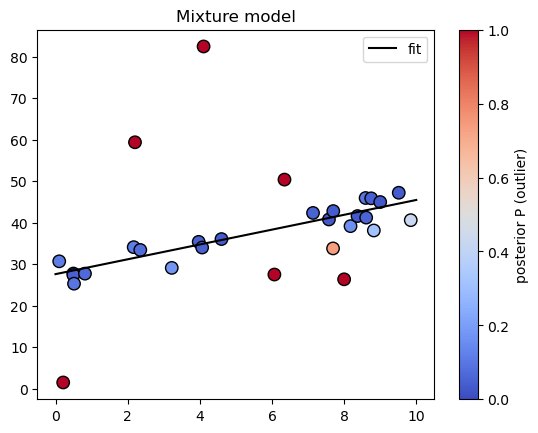

In [21]:
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma_y)
bad = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad / (good + bad)

plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P (outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'k-', label='fit')
plt.legend()
plt.title('Mixture model')
plt.show()

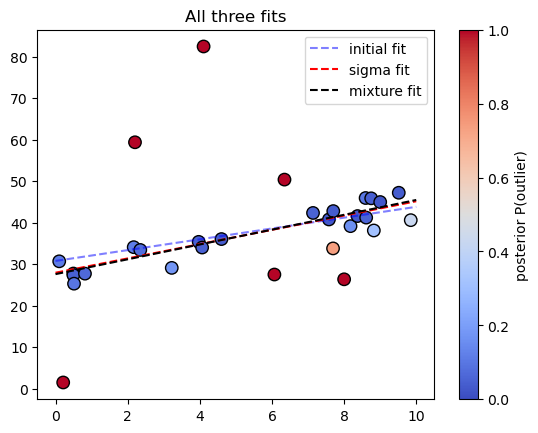

In [22]:
plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m * xx + b, 'b--', alpha=0.5, label='initial fit')
plt.plot(xx, m_k * xx + b_k, 'r--', label='sigma fit')
plt.plot(xx, m_mix * xx + b_mix, 'k--', label='mixture fit')
plt.legend()
plt.title('All three fits')
plt.show()

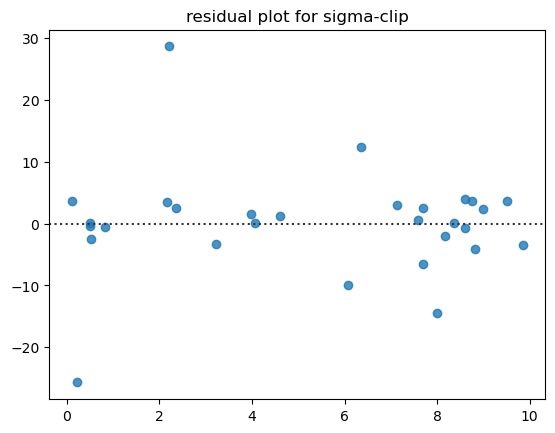

In [26]:
residplot(x=x[mask],y=y[mask])
plt.title('residual plot for sigma-clip')
plt.show()

**FINAL ANSWER:** $m = $ 1.7863 $\pm$ 0.4232 , $b = $ 27.80 $\pm$ 1.9584 , outlier fraction $\approx$ 0.2005

**Justification and uncertainty method (a short paragraph):**

For my final answer I decided to go with the mixture model slope, intercept, and uncertainties. Comparing the mixture model to the sigma-clip they produced similar fits. However the mixture model has a slightly steeper fit which is more in line with the points found not to be outliers. The mixture fit is more reliable in how it handles the stray variables. For the final uncertainties I used the bootstrapping method on my mixture model. These uncertainties bring the values within the range I would expect to see based on my other model fits.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* Within the ai report, only one outlier is removed from the fit in step 2. We see this when sigma is overestimated in a clip. Within my models, there is a greater identification of outliers which is taken into account.

*Flaw 2:* While the rescaling in step 3 results results in a reduced chi2 of 1, it also results in larger uncertainity on the slope and intercept. Along with large error bars. These don't make sense in context of the rest of the fit generated by ai. When view compared my mixture model, the ai fit is pulled away from good points.

*Flaw 3:* The rescale of step 3 is not specific to the model itself. Any model can produce a perfect reduced chi2 with the scaling method used by the ai as we saw on day 1 of lecture. It is not a meaningful choice. It would be better to reassess the fit with a mixture model rather than trying to force the data to be correct.

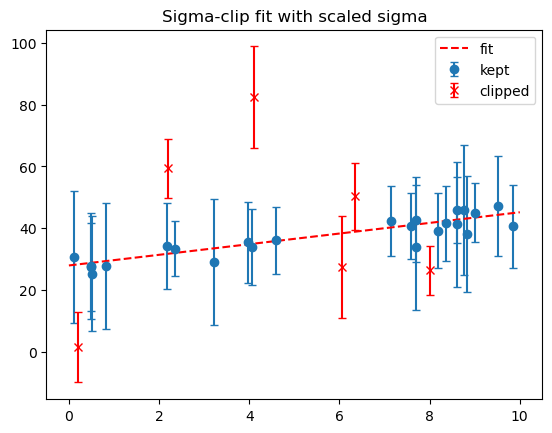

In [24]:
sigma = sigma_y * np.sqrt(chi2_reduced)
plt.errorbar(x[mask], y[mask], yerr=sigma[mask], fmt='o', capsize=3, label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma[~mask], fmt='x', capsize=3, color = 'r', label='clipped')
plt.plot(xx, m_k * xx + b_k, 'r--', label='fit')
plt.title('Sigma-clip fit with scaled sigma')
plt.legend()
plt.show()

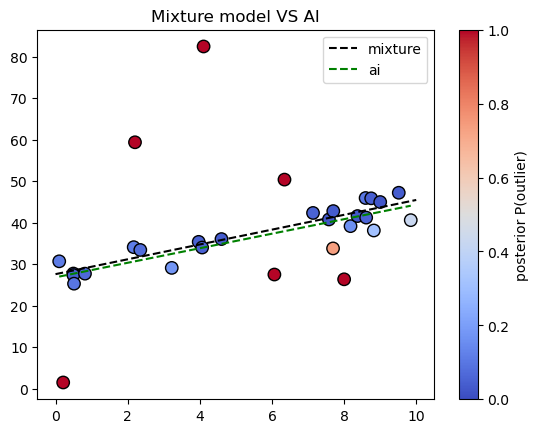

In [25]:
coeffs, cov = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))

residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
mask = np.abs(residuals) < threshold

coeffs, cov = np.polyfit(x[mask], y[mask], 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))

xg = np.linspace(x.min(), x.max(), 100)
plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'k--', label='mixture')
plt.plot(xg, m_fit * xg + b_fit, 'g--', label='ai')
plt.legend()
plt.title('Mixture model VS AI')
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

When it came to the calculated slope, intercept, and uncertainty values in part 1 I reference the ai solution for the lab. I asked Copilot how I could approach calcuating the +/- for the mixture model in part 2 as I was having trouble. One of the methods it suggested was bootstrapping so I returned to the notebook where we covered it to retry applying the method after failing to initially.

**VERIFICATION PLAN:**

For part 2, I made a residual plot for the sigma-clip alongside comparing the 3 fits on a single plot. The sigma-clip residual plot had two notable outliers that you would not expect to see. Which informed my decision to choose the mixture model over it. Plotting all three fits together alongside the liklihood of each point being an outlier helped build a better sense of performance.